# Project 3
Author: Kevin Havis

In [14]:
import nltk
from nltk.corpus import names
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Data Setup

First we will access the male and female names from the NLTK corpus of names and use that to set up our data.

In [16]:
male_names = [name for name in names.words("male.txt")]
female_names = [name for name in names.words("female.txt")]

Now we can start using the data to generate our features.

As the textbook hinted, the last letter in a name can be important. As potential features, we will include the below.

- Last letter
- Name length
- Number of vowels
- Number of consonants

We'll then build a dataframe of our features and target.

In [17]:
# Extact features
def get_n_vowels(word: str):
    vowels = 0
    for letter in word:
        if letter in "aeiouAEIOU":
            vowels += 1

    return vowels


features = {
    "last_letter": (
        [name[-1] for name in male_names] + [name[-1] for name in female_names]
    ),
    "length": (
        [len(name) for name in male_names] + [len(name) for name in female_names]
    ),
    "n_vowels": (
        [get_n_vowels(name) for name in male_names]
        + [get_n_vowels(name) for name in female_names]
    ),
    "gender": ([0 for name in male_names] + [1 for name in female_names]),
}

df = pd.DataFrame(features)

# Easier to do this here
df["n_consonants"] = df["length"] - df["n_vowels"]

df.head()


,last_letter,length,n_vowels,gender,n_consonants
0,r,5,3,0,2
1,n,5,3,0,2
2,y,5,2,0,3
3,e,5,3,0,2
4,t,5,2,0,3


### Last Letter Frequency by Gender

The last letter of a name is one of our key features. The chart below shows how often each ending letter appears for male vs. female names — letters like `a` strongly predict female names, while `n` and `r` skew male.

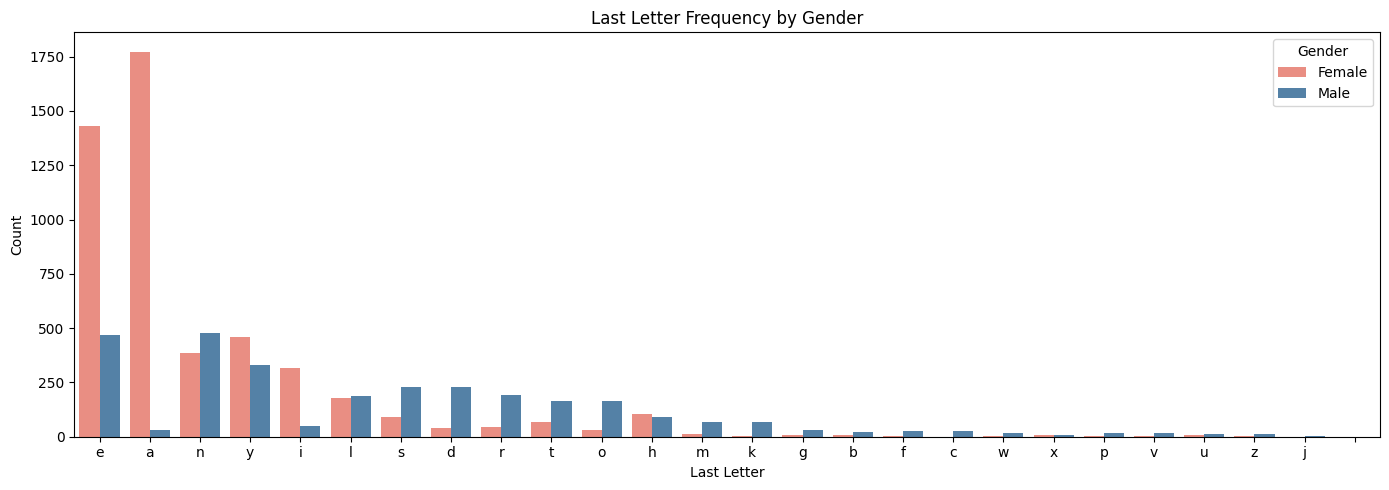

In [18]:
# Last letter frequency by gender
last_letter_counts = (
    df.groupby(["last_letter", "gender"]).size().reset_index(name="count")
)
last_letter_counts["gender_label"] = last_letter_counts["gender"].map(
    {0: "Male", 1: "Female"}
)

# Sort letters by total frequency
letter_order = (
    last_letter_counts.groupby("last_letter")["count"]
    .sum()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(
    data=last_letter_counts,
    x="last_letter",
    y="count",
    hue="gender_label",
    order=letter_order,
    palette={"Male": "steelblue", "Female": "salmon"},
    ax=ax,
)
ax.set_title("Last Letter Frequency by Gender")
ax.set_xlabel("Last Letter")
ax.set_ylabel("Count")
ax.legend(title="Gender")
plt.tight_layout()
plt.show()

Now we do our feature encoding and train / test splits. We'll use a test and holdout set of size 500 each, training on the rest of the data. This prevents overfitting in our model, allowing it to generalize better to unseen data.

In [ ]:
# Preprocess categoricals
dummies = pd.get_dummies(df["last_letter"])

X = pd.concat([df, dummies], axis=1).drop(["last_letter", "gender"], axis=1)
y = df["gender"]

# Split off 500-name test set, then 500-name holdout from the remainder
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=500, random_state=42, stratify=y
)
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X_temp, y_temp, test_size=500, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}, Holdout: {len(X_holdout)}")

Train: 6944, Test: 500, Holdout: 500


We will now build our classifier. We will increment through three modesl;

- A decision tree that uses the last letter of the name only
- A decision tree with additional features, such as the number of vowels vs consonants and overall name length
- Finally, we will train a Random Forest classifier with hyperparameter tuning and all features.

We will see that the Random forest performs the best on its test set, improving by approximately 1% in accuracy over the simpler models.

In [20]:
# Model 1 — Baseline: last letter only (single most intuitive feature)
from sklearn.tree import DecisionTreeClassifier

last_letter_cols = list(dummies.columns)

m1 = DecisionTreeClassifier(max_depth=3, random_state=42)
m1.fit(X_train[last_letter_cols], y_train)
m1_score = m1.score(X_test[last_letter_cols], y_test)
print(f"Model 1 (last letter only):          {m1_score:.4f}")

# Model 2 — Add numeric features (length, vowels, consonants)
numeric_cols = ["length", "n_vowels", "n_consonants"]
m2_cols = numeric_cols + last_letter_cols

m2 = DecisionTreeClassifier(max_depth=5, random_state=42)
m2.fit(X_train[m2_cols], y_train)
m2_score = m2.score(X_test[m2_cols], y_test)
print(f"Model 2 (+ numeric features):        {m2_score:.4f}")

# Model 3 — Tuned Random Forest over all features
params = {"max_depth": [3, 5, 10, None], "max_features": [3, 5, 10, "sqrt"]}
cv = GridSearchCV(RandomForestClassifier(random_state=42), param_grid=params, cv=5)
cv.fit(X_train, y_train)
m3_score = cv.score(X_test, y_test)
print(f"Model 3 (tuned Random Forest):       {m3_score:.4f}")
print(f"  Best params: {cv.best_params_}")

Model 1 (last letter only):          0.7420
Model 2 (+ numeric features):        0.7400
Model 3 (tuned Random Forest):       0.7500
  Best params: {'max_depth': 10, 'max_features': 5}


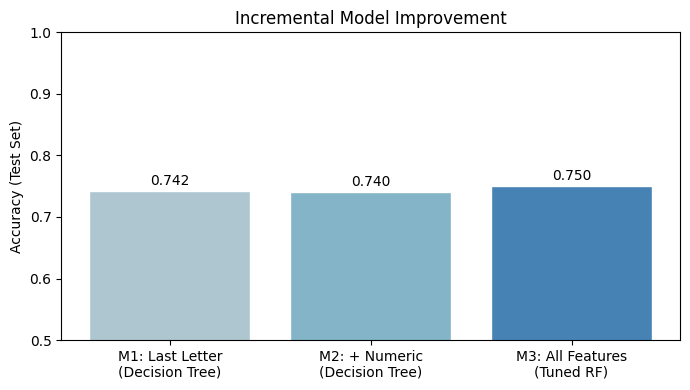

In [ ]:
# Model progression chart
model_labels = [
    "M1: Last Letter\n(Decision Tree)",
    "M2: + Numeric\n(Decision Tree)",
    "M3: All Features\n(Tuned RF)",
]
test_scores = [m1_score, m2_score, m3_score]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    model_labels,
    test_scores,
    color=["#aec6cf", "#84b4c8", "steelblue"],
    edgecolor="white",
)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Accuracy (Test Set)")
ax.set_title("Incremental Model Improvement")
for bar, score in zip(bars, test_scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{score:.3f}",
        ha="center",
        va="bottom",
    )
plt.tight_layout()
plt.show()


#### Final Model & Holdout Set

The chart below shows which features the Random Forest relied on most. The last-letter dummy variables dominate — confirming the EDA finding that certain endings are strongly gendered.

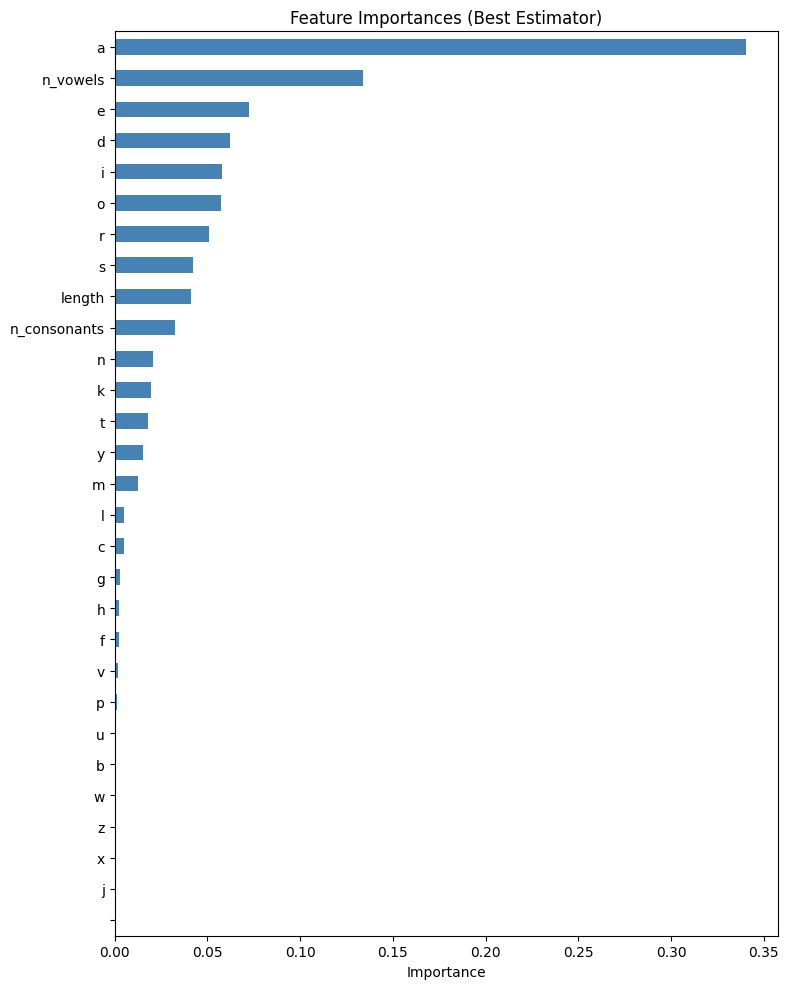

In [ ]:
# Feature importance of final model
best_est = cv.best_estimator_
importances = pd.Series(best_est.feature_importances_, index=X.columns).sort_values(
    ascending=True
)

fig, ax = plt.subplots(figsize=(8, 10))
importances.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature Importances (Best Estimator)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

We will now perform the final evaluation using the holdout set we created earlier. This will be the most representative of future data, which the model has not seen.

In [27]:
# Final model evaluation on test set
y_pred = cv.predict(X_test)
print("=== Test Set ===")
print(classification_report(y_test, y_pred, target_names=["Male", "Female"]))

=== Test Set ===
              precision    recall  f1-score   support

        Male       0.70      0.57      0.63       185
      Female       0.77      0.86      0.81       315

    accuracy                           0.75       500
   macro avg       0.74      0.71      0.72       500
weighted avg       0.74      0.75      0.74       500



In [28]:
# Holdout evaluation — only touched once, at the very end
y_holdout_pred = cv.predict(X_holdout)
holdout_score = cv.score(X_holdout, y_holdout)
print(f"=== Holdout Set (final check) === accuracy: {holdout_score:.4f}")
print(classification_report(y_holdout, y_holdout_pred, target_names=["Male", "Female"]))

=== Holdout Set (final check) === accuracy: 0.7760
              precision    recall  f1-score   support

        Male       0.70      0.68      0.69       185
      Female       0.82      0.83      0.82       315

    accuracy                           0.78       500
   macro avg       0.76      0.76      0.76       500
weighted avg       0.77      0.78      0.78       500



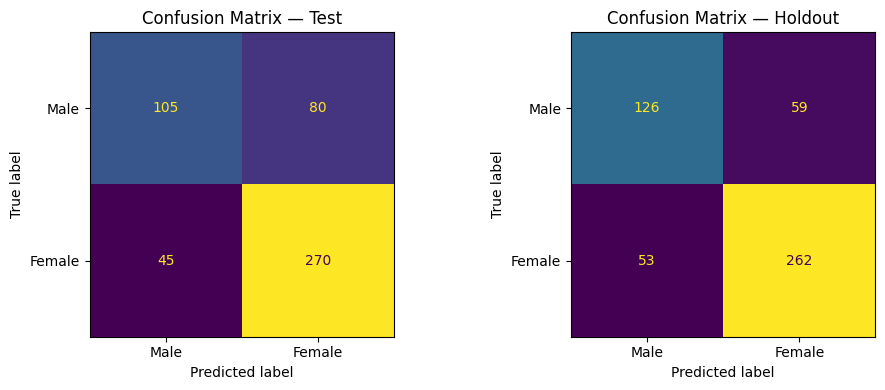

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (y_true, y_pred_vals, title) in zip(
    axes,
    [
        (y_test, y_pred, "Confusion Matrix — Test"),
        (y_holdout, y_holdout_pred, "Confusion Matrix — Holdout"),
    ],
):
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred_vals, display_labels=["Male", "Female"], ax=ax, colorbar=False
    )
    ax.set_title(title)
plt.tight_layout()
plt.show()

The accuracy on the holdout set improves over the test set, even when weighting for the proportion of female / male names. This shows us that we have succuessfully fit the model without overfitting, meaning the model will be useful for future predictions.

## Conclusion

Natural language processing is an important set of techniques that further enable us to model communications. By creating features from the names in our data, we were able to create a supervised learning model that predicted the gender associated with the name. This framework can be extended to many applications, such as topic modeling and sentiment analysis, and is an important set of tools in the data scientist's toolbox.
